=== PHASE 4: ADVANCED ANALYSIS AND VISUALIZATIONS ===

✓ Loaded previous analysis results

=== VISUALIZATION 1: LATENCY DISTRIBUTIONS ===


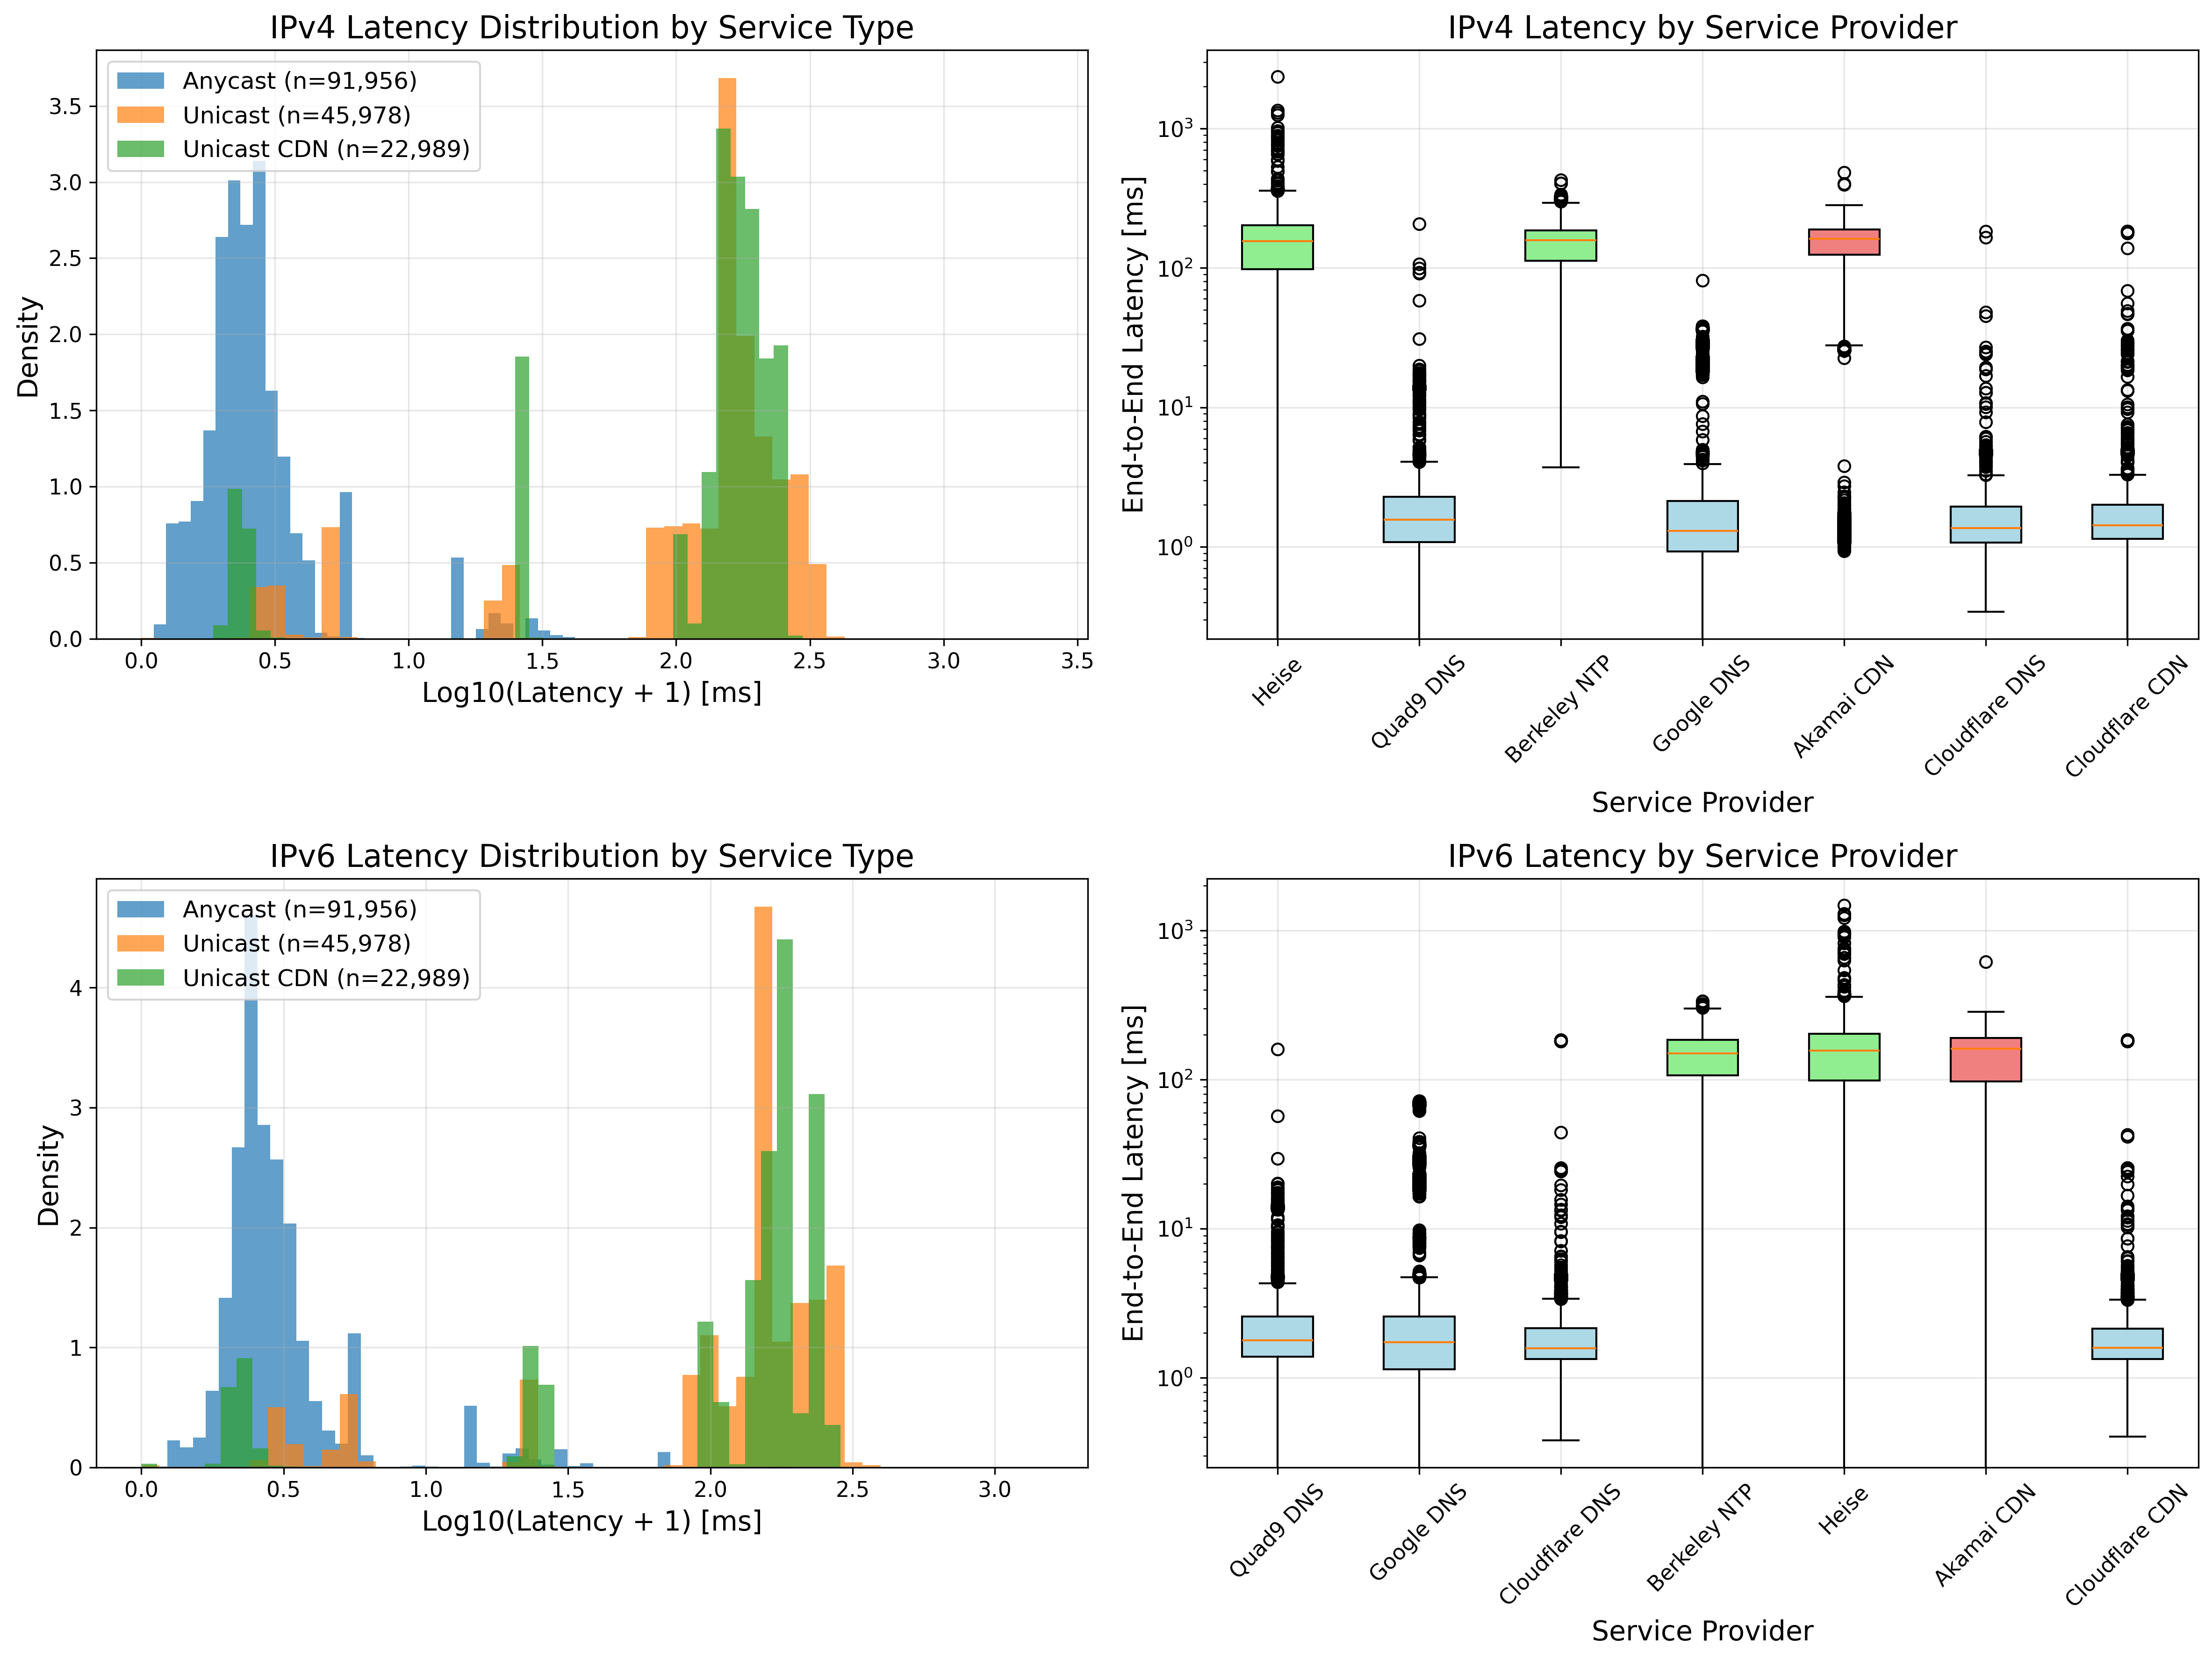

✓ Latency distribution plot saved

=== VISUALIZATION 2: HOPCOUNT vs LATENCY ANALYSIS ===


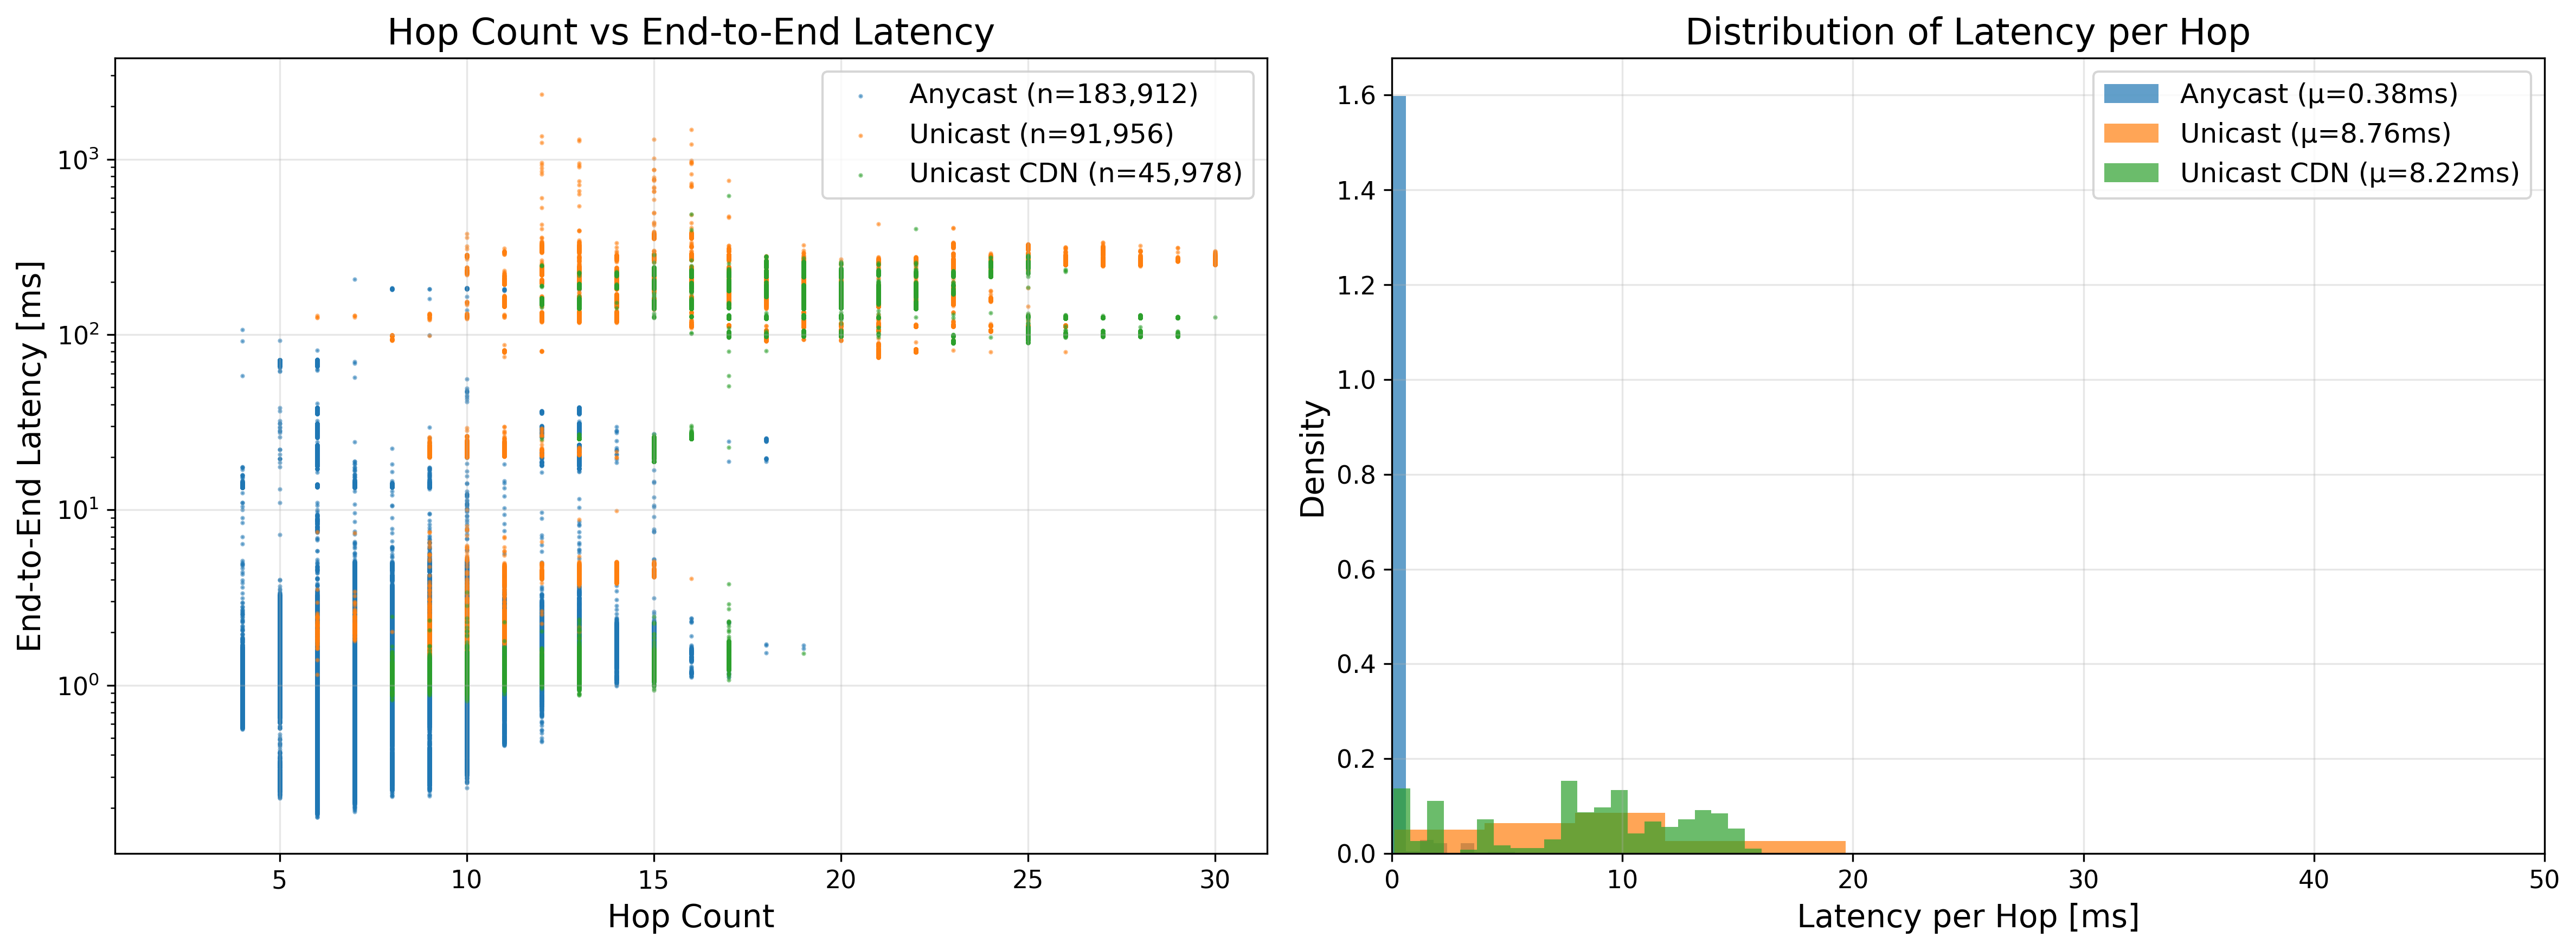

Correlation Analysis (Pearson r):
  Anycast: r = -0.012 (p < 1.41e-07)
  Unicast: r = 0.466 (p < 0.00e+00)
  Unicast CDN: r = 0.274 (p < 0.00e+00)
✓ Hop count vs latency analysis completed

=== VISUALIZATION 3: REGIONAL INFRASTRUCTURE QUALITY ===


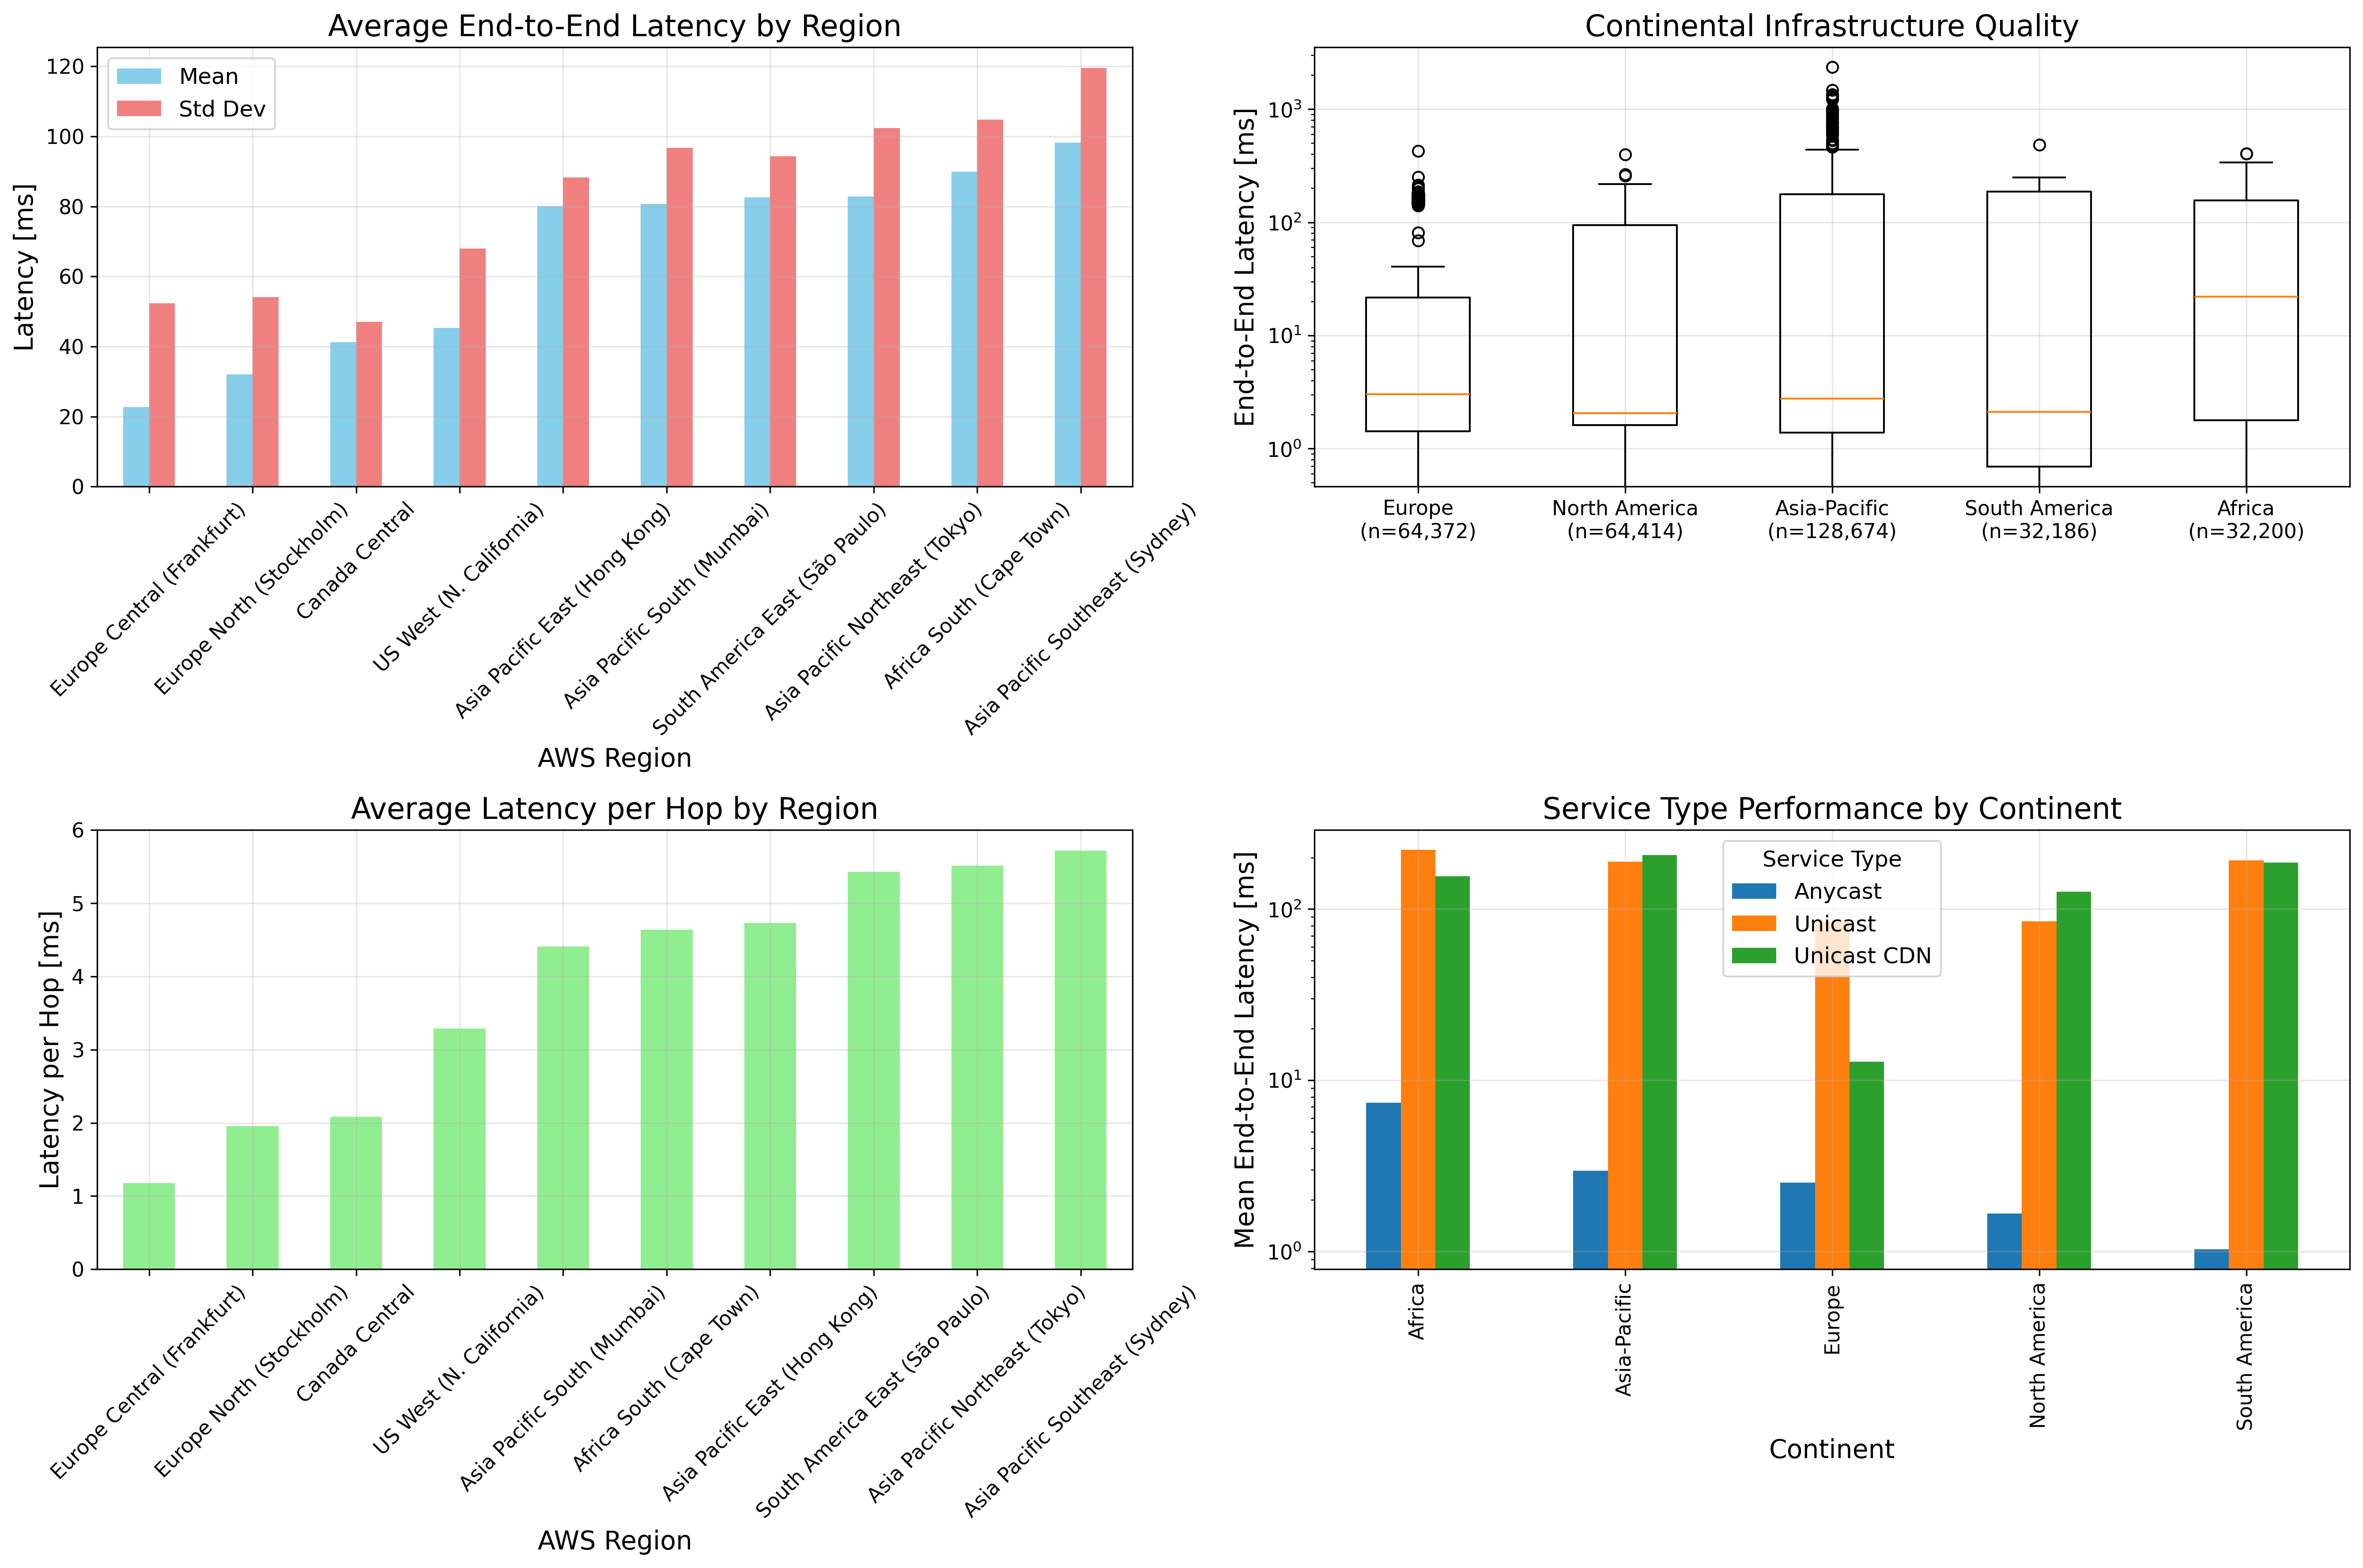

✓ Regional analysis visualization completed

=== ADVANCED ANALYSIS: ANYCAST INFRASTRUCTURE REVERSE ENGINEERING ===
Developing Anycast Infrastructure Reverse Engineering Methodology...

--- Cloudflare DNS Infrastructure Analysis ---
  Unique penultimate hop hosts: 188
  Unique penultimate ASNs: 6
  Regional latency variation (std): 1.76ms
  Hop count coefficient of variation: 21.69%
  Top penultimate ASNs (potential anycast hosts):
    AS13335: 36723 measurements
    AS???: 6892 measurements
    AS16509: 2210 measurements
    AS135217: 143 measurements
    AS3356: 6 measurements
  Estimated anycast server locations: 10

--- Google DNS Infrastructure Analysis ---
  Unique penultimate hop hosts: 780
  Unique penultimate ASNs: 3
  Regional latency variation (std): 3.19ms
  Hop count coefficient of variation: 28.42%
  Top penultimate ASNs (potential anycast hosts):
    AS15169: 45371 measurements
    AS???: 606 measurements
    AS135217: 1 measurements
  Estimated anycast server locations: 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import networkx as nx
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up publication-quality plotting
plt.rcParams.update({
    'figure.figsize': (14, 10),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

print("=== PHASE 4: ADVANCED ANALYSIS AND VISUALIZATIONS ===")
print()

# Load all datasets
df_ipv4 = pd.read_parquet("../data/IPv4.parquet")
df_ipv6 = pd.read_parquet("../data/IPv6.parquet")

# Service mappings
service_mapping = {
    '1.1.1.1': 'Cloudflare DNS', '8.8.8.8': 'Google DNS', '9.9.9.9': 'Quad9 DNS',
    '2.16.241.219': 'Akamai CDN', '104.16.123.96': 'Cloudflare CDN',
    '193.99.144.85': 'Heise', '169.229.128.134': 'Berkeley NTP',
    '2606:4700:4700::1111': 'Cloudflare DNS', '2001:4860:4860::8888': 'Google DNS',
    '2620:fe::fe:9': 'Quad9 DNS', '2a02:26f0:3500:1b::1724:a393': 'Akamai CDN',
    '2606:4700::6810:7b60': 'Cloudflare CDN', '2a02:2e0:3fe:1001:7777:772e:2:85': 'Heise',
    '2607:f140:ffff:8000:0:8006:0:a': 'Berkeley NTP'
}

service_type_mapping = {
    'Cloudflare DNS': 'Anycast', 'Google DNS': 'Anycast', 'Quad9 DNS': 'Anycast',
    'Cloudflare CDN': 'Anycast', 'Akamai CDN': 'Unicast CDN', 
    'Heise': 'Unicast', 'Berkeley NTP': 'Unicast'
}

# Add service columns
for df in [df_ipv4, df_ipv6]:
    df['service_provider'] = df['dst'].map(service_mapping)
    df['service_type'] = df['service_provider'].map(service_type_mapping)
    df['utctime'] = pd.to_datetime(df['utctime'])

df_ipv4['protocol'] = 'IPv4'
df_ipv6['protocol'] = 'IPv6'

# Load previously computed results
try:
    latency_data = pd.read_csv('../results/latency_analysis.csv')
    latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])
    hop_data = pd.read_csv('../results/hop_by_hop_analysis.csv')
    print("✓ Loaded previous analysis results")
except:
    print("⚠ Previous results not found - will compute from scratch")
    # You would need to run the extraction functions here if files don't exist

print()

print("=== VISUALIZATION 1: LATENCY DISTRIBUTIONS ===")

def create_latency_distribution_plot():
    """Create publication-quality latency distribution plots"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # IPv4 vs IPv6 comparison by service type
    for i, protocol in enumerate(['IPv4', 'IPv6']):
        protocol_data = latency_data[latency_data['protocol'] == protocol]
        
        # Latency distribution by service type
        ax = axes[i, 0]
        for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
            service_data = protocol_data[protocol_data['service_type'] == service_type]['end_to_end_latency']
            # Use log scale for better visualization due to wide range
            ax.hist(np.log10(service_data + 1), alpha=0.7, bins=50, 
                   label=f'{service_type} (n={len(service_data):,})', density=True)
        
        ax.set_xlabel('Log10(Latency + 1) [ms]')
        ax.set_ylabel('Density')
        ax.set_title(f'{protocol} Latency Distribution by Service Type')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Service provider comparison
        ax = axes[i, 1]
        service_providers = protocol_data['service_provider'].unique()
        box_data = [protocol_data[protocol_data['service_provider'] == sp]['end_to_end_latency'] 
                   for sp in service_providers]
        
        bp = ax.boxplot(box_data, labels=service_providers, patch_artist=True)
        ax.set_xlabel('Service Provider')
        ax.set_ylabel('End-to-End Latency [ms]')
        ax.set_title(f'{protocol} Latency by Service Provider')
        ax.tick_params(axis='x', rotation=45)
        ax.set_yscale('log')  # Log scale due to wide range
        ax.grid(True, alpha=0.3)
        
        # Color boxes by service type
        colors = {'Anycast': 'lightblue', 'Unicast': 'lightgreen', 'Unicast CDN': 'lightcoral'}
        for patch, provider in zip(bp['boxes'], service_providers):
            service_type = service_type_mapping[provider]
            patch.set_facecolor(colors[service_type])
    
    plt.tight_layout()
    plt.savefig('../results/latency_distributions.png')
    plt.show()
    print("✓ Latency distribution plot saved")

create_latency_distribution_plot()

print()
print("=== VISUALIZATION 2: HOPCOUNT vs LATENCY ANALYSIS ===")

def create_hopcount_latency_analysis():
    """Analyze relationship between hop count and latency"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot: Hop Count vs End-to-End Latency
    ax = axes[0]
    for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
        type_data = latency_data[latency_data['service_type'] == service_type]
        ax.scatter(type_data['hop_count'], type_data['end_to_end_latency'], 
                  alpha=0.5, s=1, label=f'{service_type} (n={len(type_data):,})')
    
    ax.set_xlabel('Hop Count')
    ax.set_ylabel('End-to-End Latency [ms]')
    ax.set_title('Hop Count vs End-to-End Latency')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Latency per hop analysis
    ax = axes[1]
    latency_per_hop_clean = latency_data[latency_data['latency_per_hop'] > 0]
    
    for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
        type_data = latency_per_hop_clean[latency_per_hop_clean['service_type'] == service_type]
        ax.hist(type_data['latency_per_hop'], alpha=0.7, bins=50, 
               label=f'{service_type} (μ={type_data["latency_per_hop"].mean():.2f}ms)', 
               density=True)
    
    ax.set_xlabel('Latency per Hop [ms]')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of Latency per Hop')
    ax.legend()
    ax.set_xlim(0, 50)  # Focus on reasonable range
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/hopcount_latency_analysis.png')
    plt.show()
    
    # Statistical correlation analysis
    print("Correlation Analysis (Pearson r):")
    for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
        type_data = latency_data[latency_data['service_type'] == service_type]
        corr, p_value = stats.pearsonr(type_data['hop_count'], type_data['end_to_end_latency'])
        print(f"  {service_type}: r = {corr:.3f} (p < {p_value:.2e})")
    
    print("✓ Hop count vs latency analysis completed")

create_hopcount_latency_analysis()

print()
print("=== VISUALIZATION 3: REGIONAL INFRASTRUCTURE QUALITY ===")

def create_regional_analysis():
    """Create regional performance comparison"""
    # Map regions to continents and locations
    region_info = {
        'us-west-1': ('North America', 'US West (N. California)'),
        'ca-central-1': ('North America', 'Canada Central'), 
        'eu-central-1': ('Europe', 'Europe Central (Frankfurt)'),
        'eu-north-1': ('Europe', 'Europe North (Stockholm)'),
        'af-south-1': ('Africa', 'Africa South (Cape Town)'),
        'ap-east-1': ('Asia-Pacific', 'Asia Pacific East (Hong Kong)'),
        'ap-south-1': ('Asia-Pacific', 'Asia Pacific South (Mumbai)'),
        'ap-northeast-1': ('Asia-Pacific', 'Asia Pacific Northeast (Tokyo)'),
        'ap-southeast-2': ('Asia-Pacific', 'Asia Pacific Southeast (Sydney)'),
        'sa-east-1': ('South America', 'South America East (São Paulo)')
    }
    
    latency_data['continent'] = latency_data['region'].map(lambda x: region_info[x][0])
    latency_data['region_name'] = latency_data['region'].map(lambda x: region_info[x][1])
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Regional latency comparison
    ax = axes[0, 0]
    regional_stats = latency_data.groupby('region_name')['end_to_end_latency'].agg(['mean', 'std']).sort_values('mean')
    regional_stats.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
    ax.set_xlabel('AWS Region')
    ax.set_ylabel('Latency [ms]')
    ax.set_title('Average End-to-End Latency by Region')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['Mean', 'Std Dev'])
    ax.grid(True, alpha=0.3)
    
    # Continental comparison
    ax = axes[0, 1]
    continental_data = []
    continents = []
    for continent in ['Europe', 'North America', 'Asia-Pacific', 'South America', 'Africa']:
        cont_data = latency_data[latency_data['continent'] == continent]['end_to_end_latency']
        continental_data.append(cont_data)
        continents.append(f'{continent}\n(n={len(cont_data):,})')
    
    ax.boxplot(continental_data, labels=continents)
    ax.set_ylabel('End-to-End Latency [ms]')
    ax.set_title('Continental Infrastructure Quality')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Latency per hop by region
    ax = axes[1, 0]
    region_hop_latency = latency_data[latency_data['latency_per_hop'] > 0].groupby('region_name')['latency_per_hop'].mean().sort_values()
    region_hop_latency.plot(kind='bar', ax=ax, color='lightgreen')
    ax.set_xlabel('AWS Region')
    ax.set_ylabel('Latency per Hop [ms]')
    ax.set_title('Average Latency per Hop by Region')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Service type performance by continent
    ax = axes[1, 1]
    cont_service_perf = latency_data.groupby(['continent', 'service_type'])['end_to_end_latency'].mean().unstack()
    cont_service_perf.plot(kind='bar', ax=ax, stacked=False)
    ax.set_xlabel('Continent')
    ax.set_ylabel('Mean End-to-End Latency [ms]')
    ax.set_title('Service Type Performance by Continent')
    ax.legend(title='Service Type')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/regional_infrastructure_quality.png')
    plt.show()
    print("✓ Regional analysis visualization completed")

create_regional_analysis()

print()
print("=== ADVANCED ANALYSIS: ANYCAST INFRASTRUCTURE REVERSE ENGINEERING ===")

def analyze_anycast_infrastructure():
    """Develop methodology to estimate anycast server locations"""
    print("Developing Anycast Infrastructure Reverse Engineering Methodology...")
    
    anycast_analysis = {}
    
    # Analyze each anycast service
    anycast_services = ['Cloudflare DNS', 'Google DNS', 'Quad9 DNS', 'Cloudflare CDN']
    
    for service in anycast_services:
        print(f"\n--- {service} Infrastructure Analysis ---")
        
        # Get all measurements for this service
        service_measurements = []
        for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
            service_data = df[df['service_provider'] == service]
            for _, row in service_data.iterrows():
                hubs = row['hubs']
                if hubs is not None and len(hubs) > 0:
                    # Get second-to-last hop (penultimate hop)
                    penultimate_hop = hubs[-2] if len(hubs) > 1 else None
                    final_hop = hubs[-1]
                    
                    # Extract infrastructure indicators
                    measurement_info = {
                        'protocol': protocol,
                        'region': row['region'],
                        'hop_count': len(hubs),
                        'final_host': final_hop.get('host', ''),
                        'final_asn': final_hop.get('ASN', ''),
                        'final_latency': final_hop.get('Avg', 0),
                        'penultimate_host': penultimate_hop.get('host', '') if penultimate_hop else '',
                        'penultimate_asn': penultimate_hop.get('ASN', '') if penultimate_hop else '',
                        'measurement_id': row['id']
                    }
                    service_measurements.append(measurement_info)
        
        service_df = pd.DataFrame(service_measurements)
        anycast_analysis[service] = service_df
        
        # Analysis 1: Unique penultimate hops (indicates different anycast locations)
        unique_penultimate = service_df['penultimate_host'].nunique()
        unique_penultimate_asns = service_df['penultimate_asn'].nunique()
        
        print(f"  Unique penultimate hop hosts: {unique_penultimate}")
        print(f"  Unique penultimate ASNs: {unique_penultimate_asns}")
        
        # Analysis 2: Regional clustering of final hop latencies
        regional_latency_stats = service_df.groupby('region')['final_latency'].agg(['mean', 'std', 'count'])
        print(f"  Regional latency variation (std): {regional_latency_stats['std'].mean():.2f}ms")
        
        # Analysis 3: Hop count consistency (lower variance suggests fewer anycast locations)
        hop_count_cv = service_df['hop_count'].std() / service_df['hop_count'].mean() * 100
        print(f"  Hop count coefficient of variation: {hop_count_cv:.2f}%")
        
        # Analysis 4: Most common penultimate ASNs (potential anycast hosting providers)
        top_penultimate_asns = service_df['penultimate_asn'].value_counts().head(5)
        print("  Top penultimate ASNs (potential anycast hosts):")
        for asn, count in top_penultimate_asns.items():
            if asn and asn != '':
                print(f"    {asn}: {count} measurements")
        
        # Estimate number of anycast locations based on clustering
        # Using k-means-like approach on latency patterns
        from sklearn.cluster import KMeans
        if len(service_df) > 10:
            # Cluster based on region and latency
            region_latency = service_df.groupby('region')['final_latency'].mean()
            n_clusters = min(len(region_latency), 10)  # Max 10 potential locations
            
            try:
                kmeans = KMeans(n_clusters=n_clusters, random_state=42)
                clusters = kmeans.fit_predict(region_latency.values.reshape(-1, 1))
                estimated_locations = len(np.unique(clusters))
                print(f"  Estimated anycast server locations: {estimated_locations}")
            except:
                print("  Could not estimate server locations via clustering")
    
    print("\n✓ Anycast infrastructure analysis completed")
    return anycast_analysis

anycast_infrastructure = analyze_anycast_infrastructure()

print()
print("=== ROUTING STABILITY ANALYSIS ===")

def analyze_routing_stability():
    """Analyze how often routing paths change for region-destination pairs"""
    print("Analyzing routing path stability...")
    
    stability_results = {}
    
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        print(f"\n--- {protocol} Routing Stability ---")
        
        path_variations = defaultdict(list)
        
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None and len(hubs) > 0:
                # Create a path signature using ASNs
                asn_path = []
                for hop in hubs:
                    asn = hop.get('ASN', '')
                    if asn and asn != 'AS???' and asn != '':
                        asn_clean = asn.replace('AS', '')
                        asn_path.append(asn_clean)
                
                if asn_path:
                    path_key = f"{row['region']}→{row['service_provider']}"
                    path_signature = '→'.join(asn_path)
                    path_variations[path_key].append(path_signature)
        
        # Calculate stability metrics
        stability_metrics = []
        for path_key, paths in path_variations.items():
            unique_paths = len(set(paths))
            total_measurements = len(paths)
            stability_ratio = 1 - (unique_paths - 1) / total_measurements if total_measurements > 1 else 1
            
            stability_metrics.append({
                'path_key': path_key,
                'unique_paths': unique_paths,
                'total_measurements': total_measurements,
                'stability_ratio': stability_ratio,
                'path_diversity': unique_paths / total_measurements
            })
        
        stability_df = pd.DataFrame(stability_metrics)
        stability_results[protocol] = stability_df
        
        # Summary statistics
        print(f"  Average unique paths per region-destination: {stability_df['unique_paths'].mean():.2f}")
        print(f"  Average stability ratio: {stability_df['stability_ratio'].mean():.3f}")
        print(f"  Most stable paths:")
        most_stable = stability_df.nlargest(3, 'stability_ratio')
        for _, row in most_stable.iterrows():
            print(f"    {row['path_key']}: {row['stability_ratio']:.3f} ({row['unique_paths']} unique paths)")
        
        print(f"  Most variable paths:")
        most_variable = stability_df.nsmallest(3, 'stability_ratio')
        for _, row in most_variable.iterrows():
            print(f"    {row['path_key']}: {row['stability_ratio']:.3f} ({row['unique_paths']} unique paths)")
    
    print("\n✓ Routing stability analysis completed")
    return stability_results

routing_stability = analyze_routing_stability()

print()
print("=== TIER 1 TRANSIT PROVIDER DETAILED ANALYSIS ===")

def analyze_tier1_usage():
    """Detailed analysis of Tier 1 transit provider usage"""
    print("Analyzing Tier 1 transit provider usage patterns...")
    
    tier1_asns = {
        '174': 'Cogent', '701': 'Verizon', '1299': 'Telia', '3320': 'Deutsche Telekom',
        '3257': 'GTT', '6453': 'TATA', '6762': 'Sparkle', '1239': 'Sprint',
        '3356': 'Level3/Lumen', '5511': 'Orange', '2914': 'NTT', '6939': 'Hurricane Electric'
    }
    
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        print(f"\n--- {protocol} Tier 1 Provider Usage ---")
        
        tier1_usage = defaultdict(lambda: defaultdict(int))
        
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None:
                path_tier1 = set()
                for hop in hubs:
                    asn = hop.get('ASN', '').replace('AS', '')
                    if asn in tier1_asns:
                        path_tier1.add(asn)
                
                # Record which Tier 1s are used for each service
                for tier1_asn in path_tier1:
                    tier1_usage[row['service_provider']][tier1_asn] += 1
        
        # Create summary
        print("  Tier 1 Usage by Service Provider:")
        for service, asn_counts in tier1_usage.items():
            if asn_counts:
                print(f"    {service}:")
                sorted_asns = sorted(asn_counts.items(), key=lambda x: x[1], reverse=True)
                for asn, count in sorted_asns:
                    provider_name = tier1_asns[asn]
                    percentage = count / 22989 * 100  # Each service has 22989 measurements
                    print(f"      AS{asn} ({provider_name}): {count:,} paths ({percentage:.1f}%)")

analyze_tier1_usage()

print()
print("=== PHASE 4 COMPLETE ===")
print("All advanced analyses completed and visualizations saved to ../results/")
print("Ready for paper structure and writing phase")